In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset/'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset'

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset'

In [ ]:
!ls '/content/drive/MyDrive/ smart_bridge_project/'

waste_classification_dataset


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/ smart_bridge_project/waste_classification_dataset/'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Define image size and batch size
IMAGE_SIZE = (224, 224) # Common size for pre-trained models
BATCH_SIZE = 32 # Standard batch size

# Create data generators for training and validation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to 0-1
    validation_split=0.2 # 20% of data for validation
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # For multi-class classification
    subset='training' # Specify this is the training subset
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' # Specify this is the validation subset
)

Found 301 images belonging to 13 classes.
Found 74 images belonging to 13 classes.


In [ ]:
# Define the number of classes (your waste categories)
num_classes = train_generator.num_classes # Gets the number of classes automatically from the generator

# Load the MobileNetV2 pre-trained model (without its top classification layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_top=False, # We don't want the original classification layer
    weights='imagenet' # Use pre-trained weights from ImageNet
)

# Freeze the layers of the base model so they are not trained
# This keeps the powerful features learned by MobileNetV2 intact
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Create the new classification layers (the "top" of your model)
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output) # Global average pooling reduces dimensionality
x = tf.keras.layers.Dense(256, activation='relu')(x) # A dense layer with ReLU activation
predictions = tf.keras.layers.Dense(num_classes, activation='softmax')(x) # Final output layer with softmax for multi-class

# Combine the base model with your new classification layers
model = tf.keras.Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# Compile the model
model.compile(
    optimizer='adam', # Adam optimizer is a good default
    loss='categorical_crossentropy', # Suitable for multi-class classification
    metrics=['accuracy'] # Track accuracy during training
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define a checkpoint to save the best model during training
# It will save the model to your Google Drive
checkpoint_filepath = '/content/drive/MyDrive/AI_Projects/best_waste_model.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Save the entire model
    monitor='val_accuracy', # Monitor validation accuracy
    mode='max', # Save when validation accuracy is maximized
    save_best_only=True # Only save the best model found so far
)

# Start training the model
# This will display training progress (epochs, loss, accuracy)
history = model.fit(
    train_generator,
    epochs=10, # You can adjust this number; 10 is a good starting point
    validation_data=validation_generator,
    callbacks=[model_checkpoint_callback]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.2951 - loss: 2.5646 

10/10 ━━━━━━━━━━━━━━━━━━━━ 233s 22s/step - accuracy: 0.3075 - loss: 2.5177 - val_accuracy: 0.7297 - val_loss: 1.1913
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8355 - loss: 0.6477

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.8371 - loss: 0.6417 - val_accuracy: 0.7973 - val_loss: 0.7320
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9441 - loss: 0.2697

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.9453 - loss: 0.2642 - val_accuracy: 0.8108 - val_loss: 0.5861
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9993 - loss: 0.0802

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.9991 - loss: 0.0800 - val_accuracy: 0.8243 - val_loss: 0.5531
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.9950 - loss: 0.0406 - val_accuracy: 0.8108 - val_loss: 0.5517
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 1.0000 - loss: 0.0268 - val_accuracy: 0.8243 - val_loss: 0.5759
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 0.8243 - val_loss: 0.5777
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.8108 - val_loss: 0.5754
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 0.8108 - val_loss: 0.5685
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 1.0000 - loss: 0.0072

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.8378 - val_loss: 0.5732


Model loaded successfully from Google Drive.


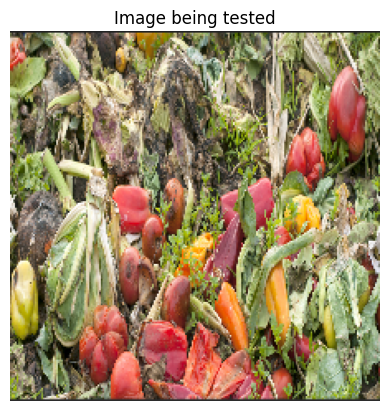


Loaded image from: /content/vegetable.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Prediction for the image:
Predicted Class: vegetable waste
Confidence: 99.46%

All Class Probabilities:
  batteries: 0.01%
  biological: 0.47%
  brown glass: 0.00%
  cardboard: 0.01%
  clothes: 0.00%
  green glass: 0.01%
  metal: 0.00%
  paper: 0.03%
  plastic: 0.01%
  shoes: 0.01%
  trash: 0.00%
  vegetable waste: 99.46%
  white glass: 0.00%


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. Load Your Trained Model ---
# MAKE SURE YOUR MODEL IS IN THIS PATH IN GOOGLE DRIVE
MODEL_PATH_IN_DRIVE = '/content/drive/MyDrive/AI_Projects/best_waste_model.h5'
try:
    loaded_model = load_model(MODEL_PATH_IN_DRIVE)
    print("Model loaded successfully from Google Drive.")
except Exception as e:
    print(f"Error loading model: {e}")
    loaded_model = None
    # IMPORTANT: If you get an error here, check if best_waste_model.h5 is truly in AI_Projects folder in your Drive.
    # And ensure Drive is mounted (from google.colab import drive; drive.mount('/content/drive')).


# --- 2. Define Your Class Names ---
# !!! VERY IMPORTANT: REPLACE THIS LIST WITH YOUR ACTUAL 12 CLASS NAMES IN ALPHABETICAL ORDER !!!
# You found this order by running `print(train_generator.class_indices)` in Colab earlier.
CLASS_NAMES = ['batteries', 'biological', 'brown glass', 'cardboard', 'clothes', 'green glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'vegetable waste', 'white glass'] # <--- ADJUST THIS LIST


# --- 3. Prepare the Image You Want to Test ---
# --- Option A: If the image is already in your Google Drive dataset ---
# Example: If you want to test a 'paper' image from your dataset
# MAKE SURE to use the correct path including the leading space for ' smart_bridge_project'
# And replace 'your_paper_image_name.jpg' with an actual image file name from that folder.
image_path = '/content/vegetable.png' # <--- ADJUST THIS PATH

# --- Option B: If you want to upload a new image from your computer to Colab for testing ---
# 1. Click the folder icon on the left sidebar in Colab (File browser).
# 2. Click the 'Upload' icon (an arrow pointing up) and select your image file (e.g., test_image.jpg).
# 3. Then use this path:
# image_path = '/content/test_image.jpg' # <--- USE THIS IF UPLOADING NEW IMAGE

# Preprocess the image
img = image.load_img(image_path, target_size=(224, 224)) # Model expects 224x224 input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension (1, 224, 224, 3)
img_array = img_array / 255.0 # Normalize pixel values to 0-1, just like training

# Display the image you're testing
plt.imshow(img)
plt.title("Image being tested")
plt.axis('off')
plt.show()

print(f"\nLoaded image from: {image_path}")


# --- 4. Make Prediction and Interpret Result ---
if loaded_model is not None:
    predictions = loaded_model.predict(img_array)[0] # Get the prediction probabilities for all classes
    predicted_class_index = np.argmax(predictions) # Get the index of the highest probability
    predicted_class_name = CLASS_NAMES[predicted_class_index] # Get the class name using the index
    confidence = float(predictions[predicted_class_index]) * 100 # Get confidence percentage

    print(f"\nPrediction for the image:")
    print(f"Predicted Class: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")
    print("\nAll Class Probabilities:")
    for i, prob in enumerate(predictions):
        print(f"  {CLASS_NAMES[i]}: {prob*100:.2f}%")
else:
    print("Model not loaded, cannot make prediction.")

In [ ]:
print(train_generator.class_indices)

{'batteries': 0, 'biological': 1, 'brown glass': 2, 'cardboard': 3, 'clothes': 4, 'green glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'vegetable waste': 11, 'white glass': 12}


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Needed for dataset visualization
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
# Example paths (adjust to your actual paths)
MODEL_PATH_IN_DRIVE = '/content/drive/MyDrive/AI_Projects/best_waste_model.h5'
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset/'

# Define your class names (MUST be in the same order as during training)
CLASS_NAMES = ['batteries', 'biological', 'brown glass', 'cardboard', 'clothes', 'green glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'vegetable waste', 'white glass']

In [7]:
from tensorflow.keras.models import Sequential, Model # Make sure Model is imported for transfer learning
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2 # Example for transfer learning

# --- Option A: Building a simple CNN from scratch ---
# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
#     MaxPooling2D((2, 2)),
#     Conv2D(64, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.5),
#     Dense(len(CLASS_NAMES), activation='softmax') # Assuming CLASS_NAMES is defined
# ])

# --- Option B: Using Transfer Learning (common for best_waste_model.h5) ---
# Ensure CLASS_NAMES is defined before this
# Example for MobileNetV2 (adjust if you used a different base model)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze the base layers for initial training

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False) # Important: set training=False for the frozen base_model
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(CLASS_NAMES), activation='softmax')(x) # Output layer for your 13 classes

model = Model(inputs, outputs) # This creates your 'model' object

print("Model architecture defined.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model architecture defined.


In [8]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use this if your labels are one-hot encoded
              # OR use 'sparse_categorical_crossentropy' if your labels are integer indices
              metrics=['accuracy'])
print("Model compiled.")

Model compiled.


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define your dataset path in Google Drive
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset/' # <--- ADJUST THIS PATH

IMAGE_SIZE = (224, 224) # Ensure this matches your model's input_shape
BATCH_SIZE = 32

# Create ImageDataGenerator for training data (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    validation_split=0.2,     # Allocate 20% of data for validation
    rotation_range=20,        # Example augmentation: rotate images up to 20 degrees
    width_shift_range=0.2,    # Shift images horizontally
    height_shift_range=0.2,   # Shift images vertically
    shear_range=0.2,          # Apply shear transformations
    zoom_range=0.2,           # Apply zoom transformations
    horizontal_flip=True,     # Flip images horizontally
    fill_mode='nearest'       # Fill in new pixels created by transformations
)

# Create ImageDataGenerator for validation data (only rescaling, no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for one-hot encoded labels (common for CNNs)
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("\nData generators created.")
# You should see output like "Found X images belonging to Y classes." for both.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define your dataset path in Google Drive
DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset/' # <--- ADJUST THIS PATH

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
    shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)


In [14]:
DATASET_PATH = '/content/drive/MyDrive/ smart_bridge_project/waste_classification_dataset'

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure DATASET_PATH is correctly set (which you just did!)
# Example: DATASET_PATH = '/content/drive/MyDrive/smart_bridge_project/waste_classification_dataset/'

IMAGE_SIZE = (224, 224) # Ensure this matches your model's expected input
BATCH_SIZE = 32

# Create ImageDataGenerator for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    # You can add other augmentations here if desired (e.g., rotation_range=20)
)

# Create ImageDataGenerator for validation data
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Create Data Generators using flow_from_directory
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for one-hot encoded labels
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)
print("\nData generators created successfully!")

Found 301 images belonging to 13 classes.
Found 74 images belonging to 13 classes.

Data generators created successfully!


In [18]:
print("\nStarting model training...")
history = model.fit(
    train_generator,
    epochs=10, # <--- Let it run for all epochs
    validation_data=val_generator,
    verbose=1
)
print("\nModel training complete. History object captured for plotting.")


Starting model training...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 97s 9s/step - accuracy: 0.2285 - loss: 2.5988 - val_accuracy: 0.5946 - val_loss: 1.5414
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - accuracy: 0.6267 - loss: 1.3058 - val_accuracy: 0.7432 - val_loss: 1.1155
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.7492 - loss: 0.8706 - val_accuracy: 0.7568 - val_loss: 0.8231
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.8245 - loss: 0.6622 - val_accuracy: 0.7838 - val_loss: 0.6729
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.8996 - loss: 0.3805 - val_accuracy: 0.8378 - val_loss: 0.5696
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.9096 - loss: 0.2891 - val_accuracy: 0.8649 - val_loss: 0.5413
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.9491 - loss: 0.2499 - val_accuracy: 0.8243 - val_loss: 0.5039
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.9579 - loss:

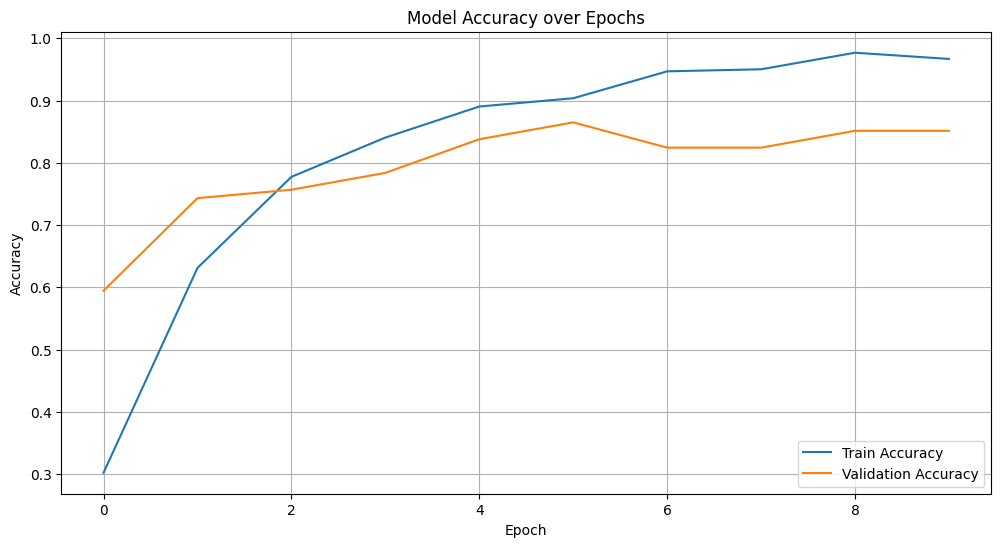

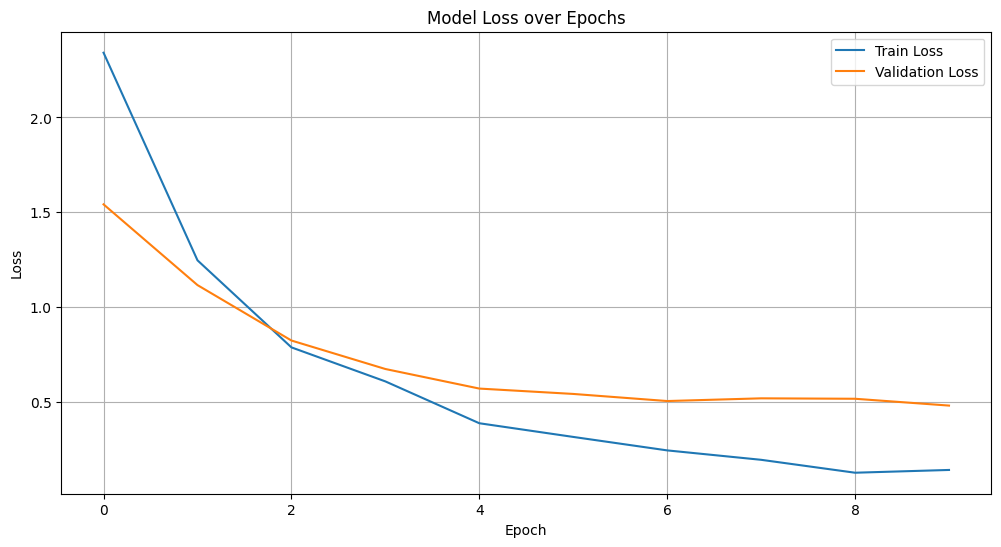

In [19]:
import matplotlib.pyplot as plt

# Ensure 'history' is the object returned by your model.fit() call

# --- Plot Training & Validation Accuracy ---
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Plot Training & Validation Loss ---
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [20]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# MAKE SURE YOUR MODEL_PATH_IN_DRIVE is correct
MODEL_PATH_IN_DRIVE = '/content/drive/MyDrive/AI_Projects/best_waste_model.h5'
try:
    loaded_model = load_model(MODEL_PATH_IN_DRIVE)
    print("Model loaded successfully from Google Drive.")
except Exception as e:
    print(f"Error loading model: {e}")
    loaded_model = None

Model loaded successfully from Google Drive.


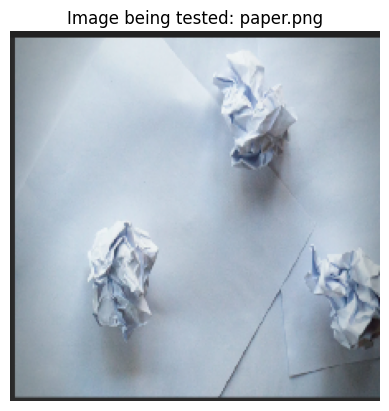

In [22]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Option A: Image from your Google Drive dataset
# IMPORTANT: Adjust this path to an actual image file in your dataset
image_path = '/content/paper.png'

# Option B: If you've uploaded a new image directly to Colab's session
# (e.g., drag and drop it into the files tab on the left)
# image_path = '/content/my_uploaded_test_image.jpg'

# Load the image
img = image.load_img(image_path, target_size=(224, 224)) # Load as a PIL Image object

# Display the image
plt.imshow(img)
plt.title(f"Image being tested: {os.path.basename(image_path)}") # Shows filename as title
plt.axis('off') # Hides axis ticks and labels
plt.show()

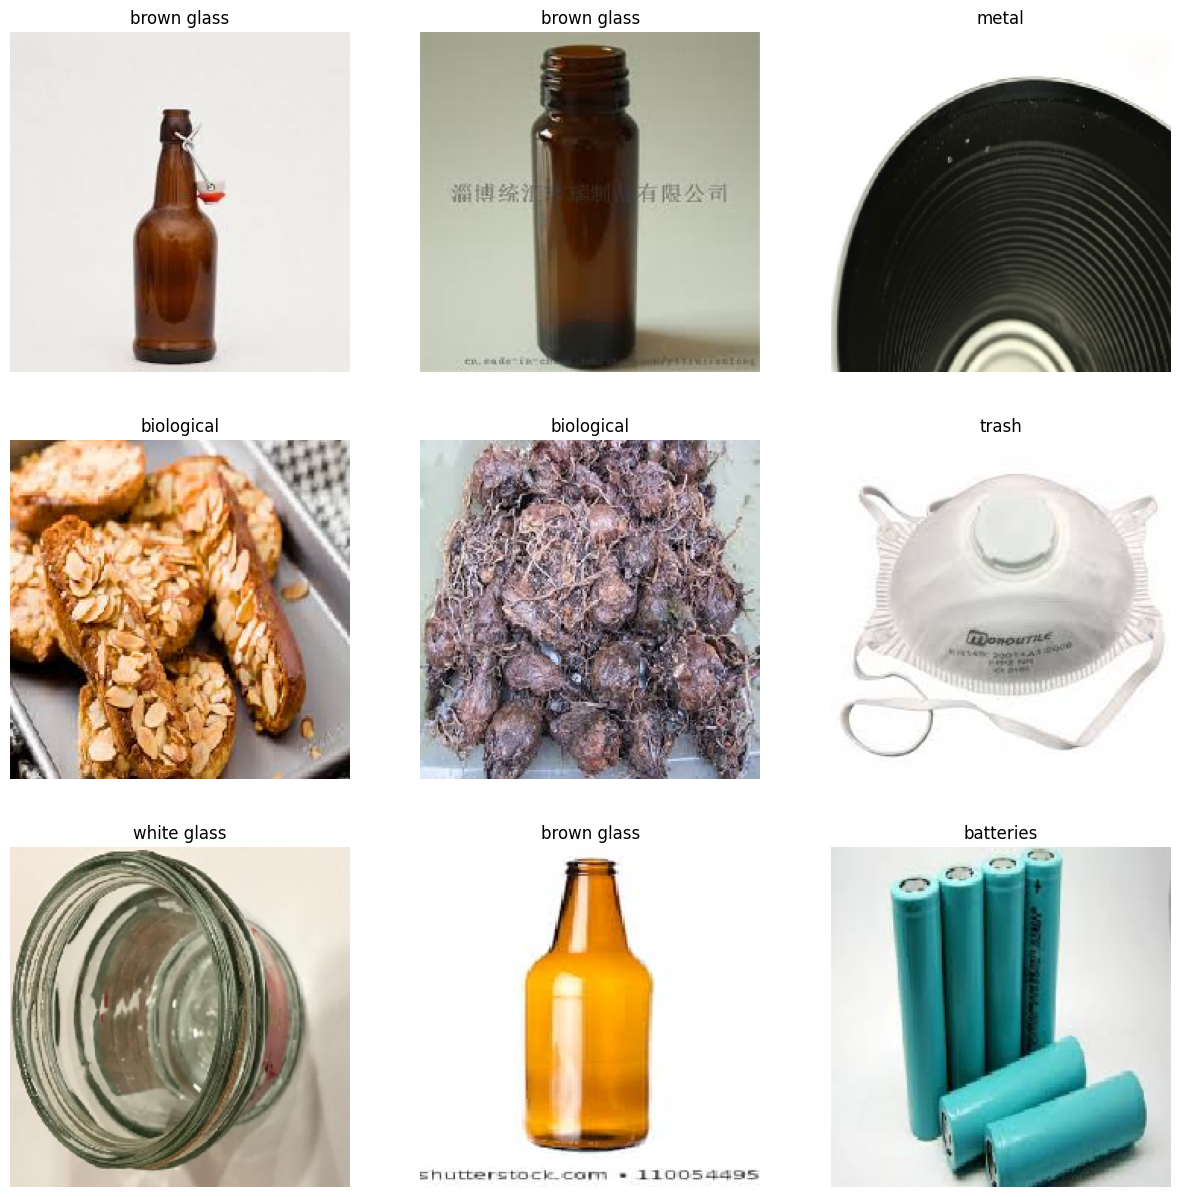

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming train_generator is already defined from Step 2
# Assuming CLASS_NAMES is already defined at the top of your notebook

# Get one batch of training images and labels
images, labels = next(train_generator)

plt.figure(figsize=(15, 15))
for i in range(min(9, images.shape[0])): # Display up to 9 images from the batch
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Convert one-hot encoded label back to class name for display
    predicted_class_index = np.argmax(labels[i])
    plt.title(CLASS_NAMES[predicted_class_index])
    plt.axis("off")
plt.show()